# Exhaustive Feature Selection

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_score

In [6]:
df = sns.load_dataset(name='iris')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [7]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

# create a logistic regression model
lr = LogisticRegression()

feature_selection = EFS(lr, max_features=4, scoring='accuracy', cv=5)

In [8]:
type(EFS(lr))

mlxtend.feature_selection.exhaustive_feature_selector.ExhaustiveFeatureSelector

Estimator yani apna model wo humna diya ha Logistic Regression          
max features vo diya ha 4               
and scoring diya ha accuracy ko                 
aor cross validation diya ha            

In [9]:
df.iloc[:,:4]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [10]:
df['species']

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

In [11]:
                    # feature        target
model = feature_selection.fit(df.iloc[:,:4],df['species'])
model

c:\Users\sumit\miniconda3\envs\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Features: 15/15

ExhaustiveFeatureSelector(estimator=LogisticRegression(),
                          feature_groups=[[0], [1], [2], [3]], max_features=4)

In [12]:
model.best_score_

0.9733333333333334

In [13]:
model.best_feature_names_

('sepal_length', 'sepal_width', 'petal_length', 'petal_width')

In [14]:
# detail subset
model.subsets_

{0: {'feature_idx': (0,),
  'cv_scores': array([0.66666667, 0.73333333, 0.76666667, 0.76666667, 0.83333333]),
  'avg_score': 0.7533333333333333,
  'feature_names': ('sepal_length',)},
 1: {'feature_idx': (1,),
  'cv_scores': array([0.53333333, 0.56666667, 0.53333333, 0.56666667, 0.63333333]),
  'avg_score': 0.5666666666666667,
  'feature_names': ('sepal_width',)},
 2: {'feature_idx': (2,),
  'cv_scores': array([0.93333333, 1.        , 0.9       , 0.93333333, 1.        ]),
  'avg_score': 0.9533333333333334,
  'feature_names': ('petal_length',)},
 3: {'feature_idx': (3,),
  'cv_scores': array([1.        , 0.96666667, 0.9       , 0.93333333, 1.        ]),
  'avg_score': 0.96,
  'feature_names': ('petal_width',)},
 4: {'feature_idx': (0, 1),
  'cv_scores': array([0.73333333, 0.83333333, 0.76666667, 0.86666667, 0.86666667]),
  'avg_score': 0.8133333333333332,
  'feature_names': ('sepal_length', 'sepal_width')},
 5: {'feature_idx': (0, 2),
  'cv_scores': array([0.93333333, 1.        , 0.9   

In [15]:
pd.DataFrame(model.subsets_).T

,feature_idx,cv_scores,avg_score,feature_names
0,"(0,)","[0.6666666666666666, 0.7333333333333333, 0.766...",0.753333,"(sepal_length,)"
1,"(1,)","[0.5333333333333333, 0.5666666666666667, 0.533...",0.566667,"(sepal_width,)"
2,"(2,)","[0.9333333333333333, 1.0, 0.9, 0.9333333333333...",0.953333,"(petal_length,)"
3,"(3,)","[1.0, 0.9666666666666667, 0.9, 0.9333333333333...",0.96,"(petal_width,)"
4,"(0, 1)","[0.7333333333333333, 0.8333333333333334, 0.766...",0.813333,"(sepal_length, sepal_width)"
5,"(0, 2)","[0.9333333333333333, 1.0, 0.9, 0.9333333333333...",0.953333,"(sepal_length, petal_length)"
6,"(0, 3)","[0.9333333333333333, 0.9666666666666667, 0.933...",0.953333,"(sepal_length, petal_width)"
7,"(1, 2)","[0.9333333333333333, 1.0, 0.9, 0.9333333333333...",0.953333,"(sepal_width, petal_length)"
8,"(1, 3)","[0.9333333333333333, 0.9666666666666667, 0.9, ...",0.94,"(sepal_width, petal_width)"
9,"(2, 3)","[0.9666666666666667, 0.9666666666666667, 0.933...",0.96,"(petal_length, petal_width)"


In [16]:
metric_df = pd.DataFrame.from_dict(model.get_metric_dict()).T
metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
0,"(0,)","[0.6666666666666666, 0.7333333333333333, 0.766...",0.753333,"(sepal_length,)",0.069612,0.05416,0.02708
1,"(1,)","[0.5333333333333333, 0.5666666666666667, 0.533...",0.566667,"(sepal_width,)",0.046932,0.036515,0.018257
2,"(2,)","[0.9333333333333333, 1.0, 0.9, 0.9333333333333...",0.953333,"(petal_length,)",0.051412,0.04,0.02
3,"(3,)","[1.0, 0.9666666666666667, 0.9, 0.9333333333333...",0.96,"(petal_width,)",0.049963,0.038873,0.019437
4,"(0, 1)","[0.7333333333333333, 0.8333333333333334, 0.766...",0.813333,"(sepal_length, sepal_width)",0.069612,0.05416,0.02708
5,"(0, 2)","[0.9333333333333333, 1.0, 0.9, 0.9333333333333...",0.953333,"(sepal_length, petal_length)",0.051412,0.04,0.02
6,"(0, 3)","[0.9333333333333333, 0.9666666666666667, 0.933...",0.953333,"(sepal_length, petal_width)",0.034274,0.026667,0.013333
7,"(1, 2)","[0.9333333333333333, 1.0, 0.9, 0.9333333333333...",0.953333,"(sepal_width, petal_length)",0.051412,0.04,0.02
8,"(1, 3)","[0.9333333333333333, 0.9666666666666667, 0.9, ...",0.94,"(sepal_width, petal_width)",0.032061,0.024944,0.012472
9,"(2, 3)","[0.9666666666666667, 0.9666666666666667, 0.933...",0.96,"(petal_length, petal_width)",0.032061,0.024944,0.012472


ya 5 times cross validaiton nikal is like sampling fir uska confidence interval or standard error nikala ha .

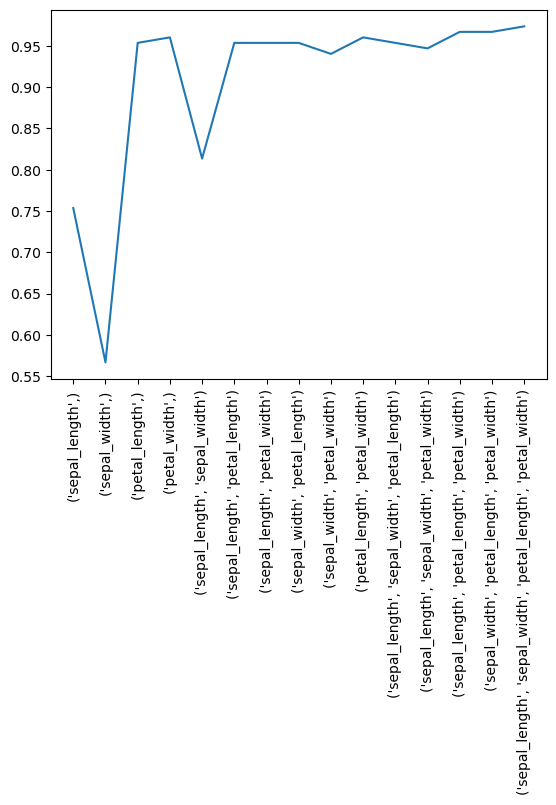

In [17]:
import matplotlib.pyplot as plt

plt.plot([str(k) for k in metric_df['feature_names']],metric_df['avg_score'])
plt.xticks(rotation=90)
plt.show()

now lets do the regression example 

In [18]:
# Boston housing data 
path = r"C:\Users\sumit\My_code_files\Data Science Projects\Boston House price predication\Boston-House-Price-Prediction\Boston.csv"
df = pd.read_csv(path)
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


In [19]:
df['MEDV']

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

In [20]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(df.iloc[:,:-1],df['MEDV'],test_size=0.2,random_state=2)

In [21]:
print(X_train.shape)
print(X_test.shape)

(404, 12)
(102, 12)


In [22]:
X_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT
321,0.18159,0.0,7.38,0,0.493,6.376,54.3,4.5404,5,287,19.6,6.87
37,0.08014,0.0,5.96,0,0.499,5.850,41.5,3.9342,5,279,19.2,8.77
286,0.01965,80.0,1.76,0,0.385,6.230,31.5,9.0892,1,241,18.2,12.93
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03
25,0.84054,0.0,8.14,0,0.538,5.599,85.7,4.4546,4,307,21.0,16.51


feature selection ka pahala hum ek baseline model train kar raha ha                 
we apply the linear regression and measure r2 score

In [23]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [24]:
# creat a baseline model 
import numpy as np
from sklearn.metrics import r2_score
model = LinearRegression()


print('training', np.mean(cross_val_score(model,X_train,y_train,cv=5,scoring='r2')))
print('testing', np.mean(cross_val_score(model,X_train,y_train,cv=5,scoring='r2')))

training 0.6956621016526537
testing 0.6956621016526537


In [25]:
lr = LinearRegression()

exh = EFS(lr,max_features=12,scoring='r2',print_progress=True,n_jobs=-1)

sel = exh.fit(X_train,y_train)

Features: 4095/4095

In [26]:
2**12 -1

4095

In [27]:
sel.best_score_

0.6967864171939278

In [28]:
sel.best_feature_names_

('0', '1', '3', '4', '5', '7', '8', '9', '10', '11')

In [29]:
index = pd.Series(sel.best_feature_names_).str[:].astype(int).values
index

array([ 0,  1,  3,  4,  5,  7,  8,  9, 10, 11])

so inka combination perform best results aap unka name bhi dek sakta ho 

In [30]:
df.columns.to_flat_index()[index]

Index(['CRIM', 'ZN', 'CHAS', 'NOX', 'RM', 'DIS', 'RAD', 'TAX', 'PTRATIO',
       'LSTAT'],
      dtype='object')

In [31]:
metric_df = pd.DataFrame.from_dict(sel.get_metric_dict()).T
metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
0,"(0,)","[0.1395311925141055, 0.1286911617868498, 0.097...",0.100384,"(0,)",0.03868,0.030094,0.015047
1,"(1,)","[0.09973503975381326, 0.06943398005233115, 0.0...",0.094404,"(1,)",0.032346,0.025166,0.012583
2,"(2,)","[0.15611087737809737, 0.21618332669297058, 0.2...",0.197943,"(2,)",0.029898,0.023262,0.011631
3,"(3,)","[0.07642066581581386, -0.023267867820460753, 0...",0.036724,"(3,)",0.04842,0.037672,0.018836
4,"(4,)","[0.18216291130080797, 0.1682116982695514, 0.03...",0.148786,"(4,)",0.093377,0.07265,0.036325
...,...,...,...,...,...,...,...
4090,"(0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11)","[0.7225482281297245, 0.7123216300628258, 0.579...",0.687761,"(0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11)",0.073606,0.057268,0.028634
4091,"(0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.7332226143334093, 0.7035619315144114, 0.580...",0.695731,"(0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.078122,0.060781,0.030391
4092,"(0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.7242016937019025, 0.696325928228082, 0.5842...",0.694424,"(0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.074041,0.057606,0.028803
4093,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.7185698623458234, 0.7061343016763003, 0.587...",0.687588,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.066128,0.05145,0.025725


In [32]:
def adjust_r2(r2,num_examples , num_features):
    coef = (num_examples - 1)/(num_examples - num_features -1)
    return 1 - (1-r2) * coef

In [33]:
metric_df['observations'] = 404
metric_df['num_features'] = metric_df['feature_idx'].apply(lambda x: len(x))
metric_df['adjusted_r2'] = adjust_r2(metric_df['avg_score'],metric_df['observations'],metric_df['num_features'])

In [34]:
metric_df.sort_values('adjusted_r2',ascending=False)

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
4057,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7321961424139276, 0.7025757405158751, 0.578...",0.696786,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11)",0.079134,0.061569,0.030784,404,10,0.689071
3957,"(0, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7241281351666664, 0.6954556268857537, 0.583...",0.695167,"(0, 3, 4, 5, 7, 8, 9, 10, 11)",0.074944,0.058309,0.029155,404,9,0.688204
4087,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7316494850301717, 0.7027333957928442, 0.578...",0.696623,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11)",0.079135,0.06157,0.030785,404,11,0.688109
4066,"(0, 2, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7236636518238793, 0.6958978706289191, 0.584...",0.695126,"(0, 2, 3, 4, 5, 7, 8, 9, 10, 11)",0.074553,0.058005,0.029003,404,10,0.687369
4091,"(0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.7332226143334093, 0.7035619315144114, 0.580...",0.695731,"(0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.078122,0.060781,0.030391,404,11,0.687193
...,...,...,...,...,...,...,...,...,...,...
0,"(0,)","[0.1395311925141055, 0.1286911617868498, 0.097...",0.100384,"(0,)",0.03868,0.030094,0.015047,404,1,0.098146
1,"(1,)","[0.09973503975381326, 0.06943398005233115, 0.0...",0.094404,"(1,)",0.032346,0.025166,0.012583,404,1,0.092151
28,"(1, 7)","[0.09575248491175792, 0.0681596171922425, 0.09...",0.093721,"(1, 7)",0.032971,0.025652,0.012826,404,2,0.089201
7,"(7,)","[0.03181123212234471, 0.016020860524337155, 0....",0.042298,"(7,)",0.025623,0.019935,0.009968,404,1,0.039916


In [35]:
X_train_sel = sel.transform(X_train)
X_test_sel = sel.transform(X_test)

In [36]:
model = LinearRegression()

print('training', np.mean(cross_val_score(model,X_train,y_train,cv=5,scoring='r2')))
print('testing', np.mean(cross_val_score(model,X_train,y_train,cv=5,scoring='r2')))

training 0.6956621016526537
testing 0.6956621016526537


Summary             
hamra pass 13 columns tha now have 10 columns and               


# Sequential Backward elimination

In [37]:
# Boston housing data 
path = r"C:\Users\sumit\My_code_files\Data Science Projects\Boston House price predication\Boston-House-Price-Prediction\Boston.csv"
df = pd.read_csv(path)
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


In [38]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(df.iloc[:,:-1],df['MEDV'],test_size=0.2,random_state=2)

In [39]:
print(X_train.shape)
print(X_test.shape)

(404, 12)
(102, 12)


In [40]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [41]:
model = LinearRegression()
print('training',np.mean(cross_val_score(model,X_train,y_train,cv=5,scoring='r2')))
print('testing',np.mean(cross_val_score(model,X_test,y_test,cv=5,scoring='r2')))

training 0.6956621016526537
testing 0.7257337909427325


In [42]:
lr = LinearRegression()

from mlxtend.feature_selection import SequentialFeatureSelector as SFS
sfs = SFS(
    estimator=lr,
    k_features='best', # aap kitna feature chaya humko best feature chaya yadi k_feature = 5 tho 5 best feature niko 
    forward=False, # aap yaha foraward ko True karo tho forward selection elemtion warna false par backward selection eliminaiton 
    floating=False, # iksa variation ha ya backward elimination ka 
    scoring='r2',
    cv = 5
)

sfs.fit(X_train,y_train)

SequentialFeatureSelector(estimator=LinearRegression(), forward=False,
                          k_features=(1, 12), scoring='r2')

$\frac {n(n + 1)}{2}$

$\frac {12 . 13}{2} = 78$

In [43]:
(12 * 13)/2

78.0

78 combination we try 

In [44]:
sfs.k_feature_idx_

(0, 1, 3, 4, 5, 7, 8, 9, 10, 11)

deko ya par bhi same result aya wahi same 10 columns ki bhat kar raha ha            
tho exhastive feature selction or backward feature elimination same result da raha ha                   
deko isna code ko kitni baar run kiya 

In [45]:
metric_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
12,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.7327310324500227, 0.7037366913210352, 0.579...",0.695662,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.078157,0.060809,0.030404
11,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7316494850301718, 0.7027333957928442, 0.578...",0.696623,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11)",0.079135,0.06157,0.030785
10,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7321961424139276, 0.7025757405158752, 0.578...",0.696786,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11)",0.079134,0.061569,0.030784
9,"(0, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7241281351666664, 0.6954556268857537, 0.583...",0.695167,"(0, 3, 4, 5, 7, 8, 9, 10, 11)",0.074944,0.058309,0.029155
8,"(0, 3, 4, 5, 7, 8, 10, 11)","[0.7140230266967262, 0.6912482233867199, 0.569...",0.688889,"(0, 3, 4, 5, 7, 8, 10, 11)",0.079831,0.062112,0.031056
7,"(3, 4, 5, 7, 8, 10, 11)","[0.7016380603335268, 0.6948853205295485, 0.577...",0.682135,"(3, 4, 5, 7, 8, 10, 11)",0.06847,0.053272,0.026636
6,"(3, 4, 5, 7, 10, 11)","[0.6982463652603103, 0.6917217817124804, 0.572...",0.680204,"(3, 4, 5, 7, 10, 11)",0.070912,0.055172,0.027586
5,"(4, 5, 7, 10, 11)","[0.6865438329224955, 0.7016611364710303, 0.568...",0.669863,"(4, 5, 7, 10, 11)",0.065367,0.050858,0.025429
4,"(5, 7, 10, 11)","[0.6639573070541647, 0.6745827090626904, 0.573...",0.658268,"(5, 7, 10, 11)",0.055791,0.043407,0.021704
3,"(5, 10, 11)","[0.650718904385023, 0.6551950158210181, 0.5461...",0.641876,"(5, 10, 11)",0.063392,0.049321,0.024661


In [46]:
def adjust_r2(r2,num_examples , num_features):
    coef = (num_examples - 1)/(num_examples - num_features -1)
    return 1 - (1-r2) * coef

In [47]:
metric_df['observations'] = 404
metric_df['num_features'] = metric_df['feature_idx'].apply(lambda x: len(x))
metric_df['adjusted_r2'] = adjust_r2(metric_df['avg_score'],metric_df['observations'],metric_df['num_features'])

In [48]:
metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
12,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.7327310324500227, 0.7037366913210352, 0.579...",0.695662,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.078157,0.060809,0.030404,404,12,0.686322
11,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7316494850301718, 0.7027333957928442, 0.578...",0.696623,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11)",0.079135,0.06157,0.030785,404,11,0.688109
10,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7321961424139276, 0.7025757405158752, 0.578...",0.696786,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11)",0.079134,0.061569,0.030784,404,10,0.689071
9,"(0, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7241281351666664, 0.6954556268857537, 0.583...",0.695167,"(0, 3, 4, 5, 7, 8, 9, 10, 11)",0.074944,0.058309,0.029155,404,9,0.688204
8,"(0, 3, 4, 5, 7, 8, 10, 11)","[0.7140230266967262, 0.6912482233867199, 0.569...",0.688889,"(0, 3, 4, 5, 7, 8, 10, 11)",0.079831,0.062112,0.031056,404,8,0.682588
7,"(3, 4, 5, 7, 8, 10, 11)","[0.7016380603335268, 0.6948853205295485, 0.577...",0.682135,"(3, 4, 5, 7, 8, 10, 11)",0.06847,0.053272,0.026636,404,7,0.676516
6,"(3, 4, 5, 7, 10, 11)","[0.6982463652603103, 0.6917217817124804, 0.572...",0.680204,"(3, 4, 5, 7, 10, 11)",0.070912,0.055172,0.027586,404,6,0.675371
5,"(4, 5, 7, 10, 11)","[0.6865438329224955, 0.7016611364710303, 0.568...",0.669863,"(4, 5, 7, 10, 11)",0.065367,0.050858,0.025429,404,5,0.665715
4,"(5, 7, 10, 11)","[0.6639573070541647, 0.6745827090626904, 0.573...",0.658268,"(5, 7, 10, 11)",0.055791,0.043407,0.021704,404,4,0.654842
3,"(5, 10, 11)","[0.650718904385023, 0.6551950158210181, 0.5461...",0.641876,"(5, 10, 11)",0.063392,0.049321,0.024661,404,3,0.63919


In [49]:
metric_df.sort_values('adjusted_r2',ascending=False)

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
10,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7321961424139276, 0.7025757405158752, 0.578...",0.696786,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11)",0.079134,0.061569,0.030784,404,10,0.689071
9,"(0, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7241281351666664, 0.6954556268857537, 0.583...",0.695167,"(0, 3, 4, 5, 7, 8, 9, 10, 11)",0.074944,0.058309,0.029155,404,9,0.688204
11,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7316494850301718, 0.7027333957928442, 0.578...",0.696623,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11)",0.079135,0.06157,0.030785,404,11,0.688109
12,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.7327310324500227, 0.7037366913210352, 0.579...",0.695662,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.078157,0.060809,0.030404,404,12,0.686322
8,"(0, 3, 4, 5, 7, 8, 10, 11)","[0.7140230266967262, 0.6912482233867199, 0.569...",0.688889,"(0, 3, 4, 5, 7, 8, 10, 11)",0.079831,0.062112,0.031056,404,8,0.682588
7,"(3, 4, 5, 7, 8, 10, 11)","[0.7016380603335268, 0.6948853205295485, 0.577...",0.682135,"(3, 4, 5, 7, 8, 10, 11)",0.06847,0.053272,0.026636,404,7,0.676516
6,"(3, 4, 5, 7, 10, 11)","[0.6982463652603103, 0.6917217817124804, 0.572...",0.680204,"(3, 4, 5, 7, 10, 11)",0.070912,0.055172,0.027586,404,6,0.675371
5,"(4, 5, 7, 10, 11)","[0.6865438329224955, 0.7016611364710303, 0.568...",0.669863,"(4, 5, 7, 10, 11)",0.065367,0.050858,0.025429,404,5,0.665715
4,"(5, 7, 10, 11)","[0.6639573070541647, 0.6745827090626904, 0.573...",0.658268,"(5, 7, 10, 11)",0.055791,0.043407,0.021704,404,4,0.654842
3,"(5, 10, 11)","[0.650718904385023, 0.6551950158210181, 0.5461...",0.641876,"(5, 10, 11)",0.063392,0.049321,0.024661,404,3,0.63919


In [50]:
import matplotlib.pyplot as plt

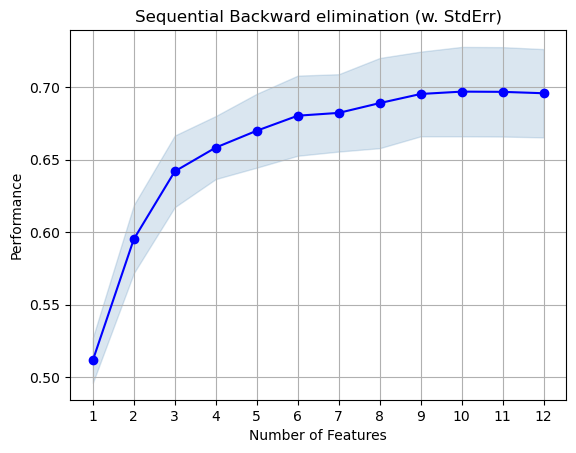

In [51]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig1 = plot_sfs(sfs.get_metric_dict(),kind='std_err')

plt.title('Sequential Backward elimination (w. StdErr)')
plt.grid()
plt.show()

In [52]:
X_train_sel = sfs.transform(X_train)
X_test_sel = sfs.transform(X_test)

model = LinearRegression()

print('training', np.mean(cross_val_score(model,X_train,y_train,cv=5,scoring='r2')))
print('testing', np.mean(cross_val_score(model,X_train,y_train,cv=5,scoring='r2')))

training 0.6956621016526537
testing 0.6956621016526537


In [53]:
X_train_sel.shape

(404, 10)

tho hamra paas 10 best columns aa raha ha 

# Sequential Forward Selection 

In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_score

In [55]:
# Boston housing data 
path = r"C:\Users\sumit\My_code_files\Data Science Projects\Boston House price predication\Boston-House-Price-Prediction\Boston.csv"
df = pd.read_csv(path)
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


In [56]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(df.iloc[:,:-1],df['MEDV'],test_size=0.2,random_state=2)

In [57]:
print(X_train.shape)
print(X_test.shape)

(404, 12)
(102, 12)


In [59]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [61]:
model = LinearRegression()

print('training',np.mean(cross_val_score(model,X_train,y_train,cv=5,scoring='r2')))
print('testing',np.mean(cross_val_score(model,X_test,y_test,cv=5,scoring='r2')))

training 0.6956621016526539
testing 0.7257337909427324


In [63]:
lr = LinearRegression()

from mlxtend.feature_selection import SequentialFeatureSelector as SFS 
sfs = SFS(
    estimator=lr,
    k_features='best',
    forward=True, # now ab ya true hona par forward Selection bana ga
    floating=False,
    scoring='r2',
    cv = 5
)

sfs.fit(X_train,y_train)

SequentialFeatureSelector(estimator=LinearRegression(), k_features=(1, 12),
                          scoring='r2')

In [64]:
sfs.k_feature_idx_

(0, 1, 3, 4, 5, 7, 8, 9, 10, 11)

In [65]:
metric_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
1,"(11,)","[0.5105776182714135, 0.5582189701867164, 0.460...",0.5117,"(11,)",0.039979,0.031105,0.015552
2,"(5, 11)","[0.6273470340408478, 0.6196588940131587, 0.502...",0.595175,"(5, 11)",0.060292,0.046909,0.023454
3,"(5, 10, 11)","[0.650718904385023, 0.6551950158210181, 0.5461...",0.641876,"(5, 10, 11)",0.063392,0.049321,0.024661
4,"(5, 7, 10, 11)","[0.6639573070541647, 0.6745827090626906, 0.573...",0.658268,"(5, 7, 10, 11)",0.055791,0.043407,0.021704
5,"(4, 5, 7, 10, 11)","[0.6865438329224955, 0.7016611364710303, 0.568...",0.669863,"(4, 5, 7, 10, 11)",0.065367,0.050858,0.025429
6,"(3, 4, 5, 7, 10, 11)","[0.6982463652603101, 0.6917217817124803, 0.572...",0.680204,"(3, 4, 5, 7, 10, 11)",0.070912,0.055172,0.027586
7,"(3, 4, 5, 7, 8, 10, 11)","[0.7016380603335268, 0.6948853205295484, 0.577...",0.682135,"(3, 4, 5, 7, 8, 10, 11)",0.06847,0.053272,0.026636
8,"(0, 3, 4, 5, 7, 8, 10, 11)","[0.7140230266967262, 0.6912482233867199, 0.569...",0.688889,"(0, 3, 4, 5, 7, 8, 10, 11)",0.079831,0.062112,0.031056
9,"(0, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7241281351666664, 0.6954556268857537, 0.583...",0.695167,"(0, 3, 4, 5, 7, 8, 9, 10, 11)",0.074944,0.058309,0.029155
10,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7321961424139276, 0.7025757405158752, 0.578...",0.696786,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11)",0.079134,0.061569,0.030784


In [68]:
def adjust_r2(r2,num_examples , num_features):
    coef = (num_examples - 1)/(num_examples - num_features -1)
    return 1 - (1-r2) * coef

In [70]:
metric_df['observations'] = 404
metric_df['num_features'] = metric_df['feature_idx'].apply(lambda x: len(x))
metric_df['adjusted_r2'] = adjust_r2(metric_df['avg_score'],metric_df['observations'],metric_df['num_features'])

In [71]:
metric_df.sort_values('adjusted_r2',ascending=False)

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
10,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7321961424139276, 0.7025757405158752, 0.578...",0.696786,"(0, 1, 3, 4, 5, 7, 8, 9, 10, 11)",0.079134,0.061569,0.030784,404,10,0.689071
9,"(0, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7241281351666664, 0.6954556268857537, 0.583...",0.695167,"(0, 3, 4, 5, 7, 8, 9, 10, 11)",0.074944,0.058309,0.029155,404,9,0.688204
11,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11)","[0.7316494850301718, 0.7027333957928441, 0.578...",0.696623,"(0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11)",0.079135,0.06157,0.030785,404,11,0.688109
12,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.7327310324500225, 0.703736691321035, 0.5799...",0.695662,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.078157,0.060809,0.030404,404,12,0.686322
8,"(0, 3, 4, 5, 7, 8, 10, 11)","[0.7140230266967262, 0.6912482233867199, 0.569...",0.688889,"(0, 3, 4, 5, 7, 8, 10, 11)",0.079831,0.062112,0.031056,404,8,0.682588
7,"(3, 4, 5, 7, 8, 10, 11)","[0.7016380603335268, 0.6948853205295484, 0.577...",0.682135,"(3, 4, 5, 7, 8, 10, 11)",0.06847,0.053272,0.026636,404,7,0.676516
6,"(3, 4, 5, 7, 10, 11)","[0.6982463652603101, 0.6917217817124803, 0.572...",0.680204,"(3, 4, 5, 7, 10, 11)",0.070912,0.055172,0.027586,404,6,0.675371
5,"(4, 5, 7, 10, 11)","[0.6865438329224955, 0.7016611364710303, 0.568...",0.669863,"(4, 5, 7, 10, 11)",0.065367,0.050858,0.025429,404,5,0.665715
4,"(5, 7, 10, 11)","[0.6639573070541647, 0.6745827090626906, 0.573...",0.658268,"(5, 7, 10, 11)",0.055791,0.043407,0.021704,404,4,0.654842
3,"(5, 10, 11)","[0.650718904385023, 0.6551950158210181, 0.5461...",0.641876,"(5, 10, 11)",0.063392,0.049321,0.024661,404,3,0.63919


In [72]:
import matplotlib.pyplot as plt

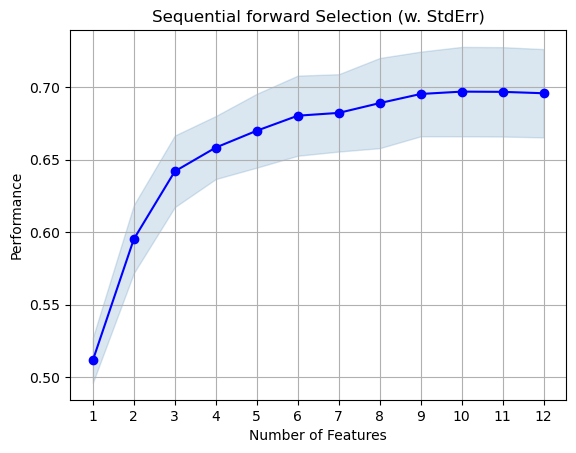

In [73]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig1 = plot_sfs(sfs.get_metric_dict(),kind='std_err')

plt.title('Sequential forward Selection (w. StdErr)')
plt.grid()
plt.show()

In [74]:
X_train_sel = sfs.transform(X_train)
X_test_sel = sfs.transform(X_test)

model = LinearRegression()

print('training', np.mean(cross_val_score(model,X_train,y_train,cv=5,scoring='r2')))
print('testing', np.mean(cross_val_score(model,X_train,y_train,cv=5,scoring='r2')))

training 0.6956621016526539
testing 0.6956621016526539


In [75]:
# after feature selection
X_train_sel.shape

(404, 10)

In [77]:
from sklearn.feature_selection import SequentialFeatureSelector as SFS

sfs2 = SFS(
    estimator=model,
    n_features_to_select=5,
    direction='forward',
    scoring='r2',
    n_jobs=-1,
    cv=5
)
sfs2.fit(X_train,y_train)

SequentialFeatureSelector(estimator=LinearRegression(), n_features_to_select=5,
                          n_jobs=-1, scoring='r2')

In [80]:
sfs2.fit(X_train,y_train).support_

array([False, False, False, False,  True,  True, False,  True, False,
       False,  True,  True])

In [85]:
df.columns.to_flat_index

<bound method Index.to_flat_index of Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'LSTAT', 'MEDV'],
      dtype='object')>

In [90]:
len(sfs2.fit(X_train,y_train).support_)

12

In [98]:
# input features
df.iloc[:,:-1].columns.to_numpy()

array(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
       'TAX', 'PTRATIO', 'LSTAT'], dtype=object)

In [ ]:
# apply the boolean indexing on it 
df.iloc[:,:-1].columns.to_numpy()[sfs2.fit(X_train,y_train).support_]

array(['NOX', 'RM', 'DIS', 'PTRATIO', 'LSTAT'], dtype=object)